# Introduction

This notebook includes the solution for Fashion-MNIST using PyTorch.  

We are loading the data from `torchvision.datasets` (`Fashion-MNIST`).  

The model includes Batch Normalization and Dropout.



# Import packages

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms


# Configuration & Data Loading

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

We will use a train/valid split (we divide the train data in train & validation set).


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)


100%|██████████| 26.4M/26.4M [00:01<00:00, 20.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 304kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]


As before, we divide the dataset into training and validation subsets. Maintaining a separate validation set is essential because later sections of this chapter will repeatedly compare experimental configurations using validation accuracy.
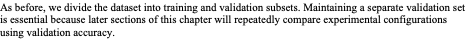
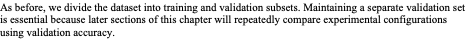
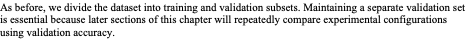
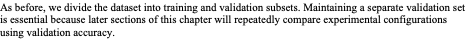

In [4]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)

# Data visualization

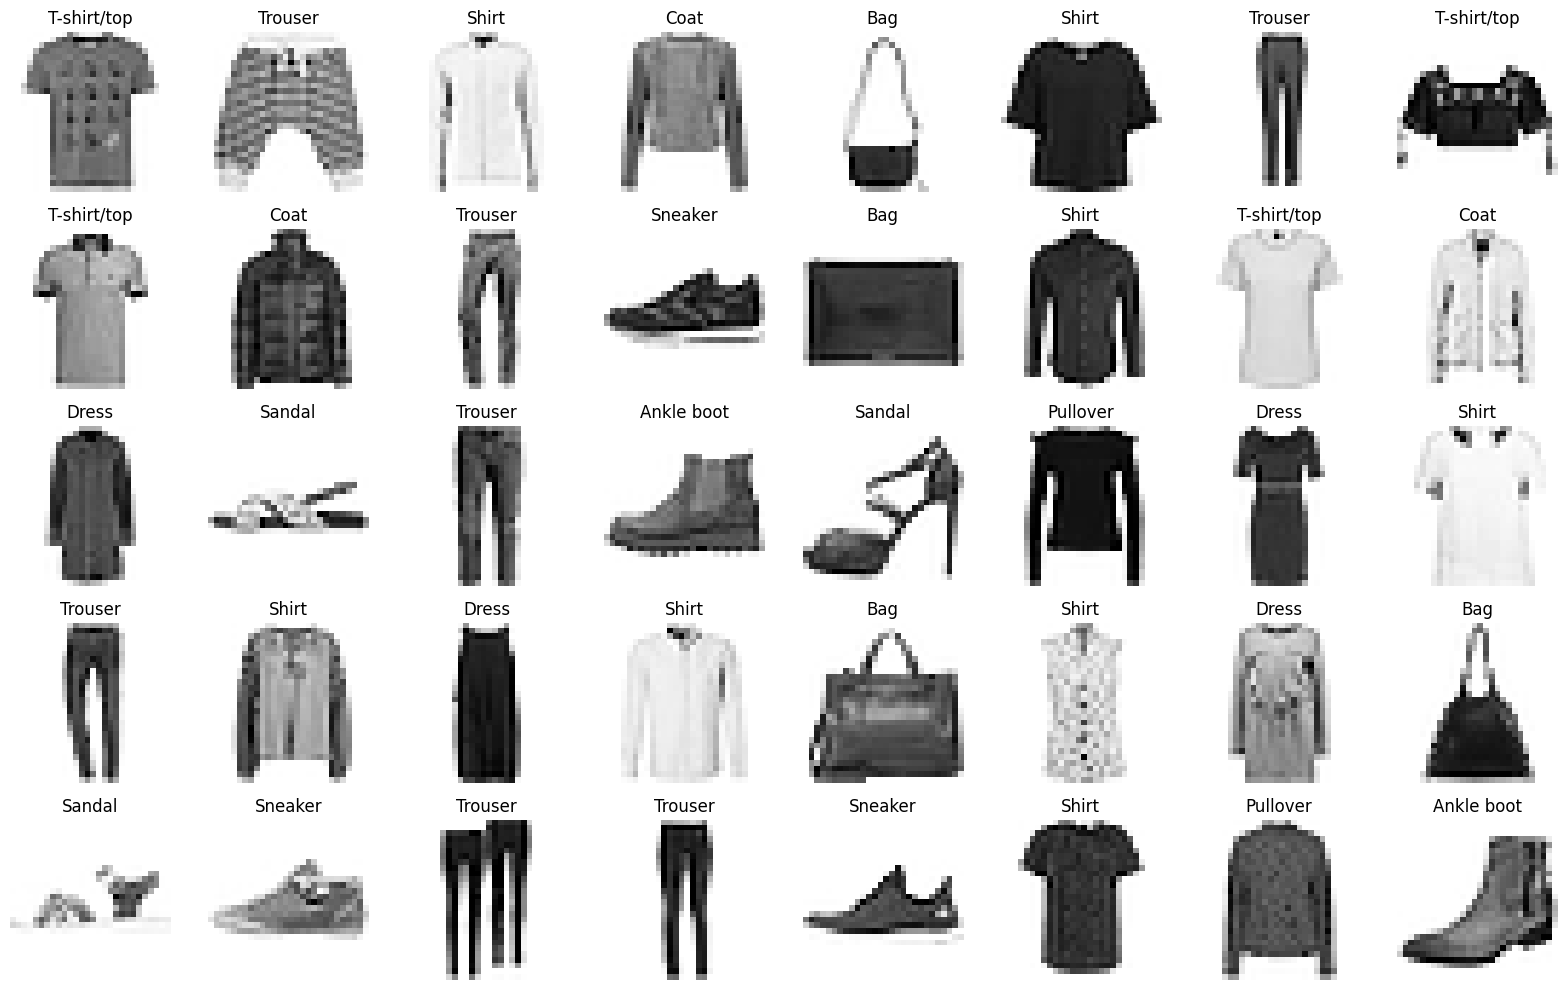

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import random

labels = dataset.classes  # ['T-shirt/top', 'Trouser', ...]

def plot_fashion_mnist(dataset, n_samples=40, cmap="gray"):
    fig, ax = plt.subplots(5, 8, figsize=(16, 10))

    indices = random.sample(range(len(dataset)), n_samples)

    for i, idx in enumerate(indices):
        img, label = dataset[idx]

        # Convert tensor (1, 28, 28) -> (28, 28)
        if hasattr(img, "numpy"):
            img = img.squeeze().numpy()

        ax[i // 8, i % 8].imshow(img, cmap=cmap)
        ax[i // 8, i % 8].axis("off")
        ax[i // 8, i % 8].set_title(labels[label])

    plt.tight_layout()
    plt.show()

plot_fashion_mnist(dataset, cmap="Grays")

# Model Definition

In [6]:
class FashionCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = FashionCNN().to(device)


# Loss & Optimization

The final layer contains ten outputs corresponding to the ten Fashion-MNIST classes. Since this is a multi-class classification problem, cross-entropy loss remains an appropriate objective function. We will initially use the Adam optimizer with a learning rate of 0.001, which provides a strong baseline for many convolutional architectures.
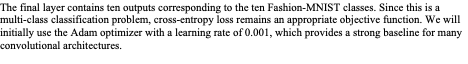
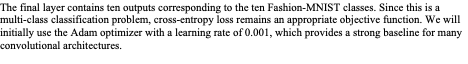
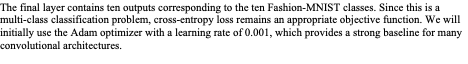
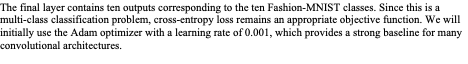

In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)


# One epoch train

To keep the workflow reusable, we separate training and validation into dedicated functions. This structure becomes increasingly important once experiment tracking and hyperparameter optimization are introduced later in the chapter. The training loop computes gradients and updates the model weights through backpropagation.
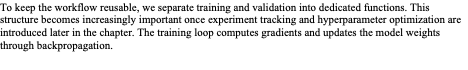
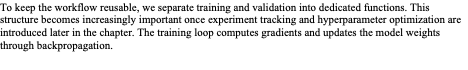
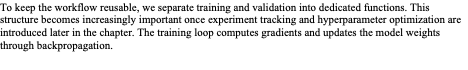
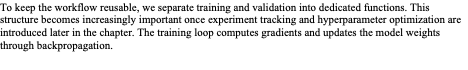

In [8]:
def train_one_epoch(model, loader):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


# Validation

Validation follows a similar structure, but gradients are disabled because the model parameters are no longer updated.
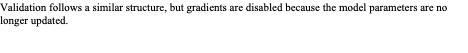
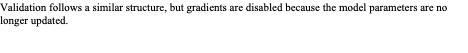
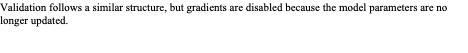
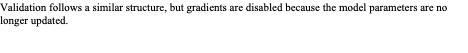

In [9]:
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


# Train the model

The full training process now becomes concise and reusable.
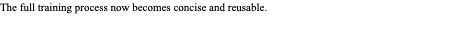
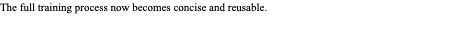
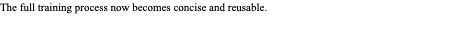
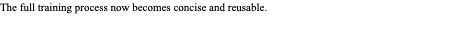

In [10]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader
    )
    val_loss, val_acc = validate(
        model,
        val_loader
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


Epoch 1/5 | Train Loss: 0.4502 | Train Acc: 0.8366 | Val Loss: 0.2985 | Val Acc: 0.8931
Epoch 2/5 | Train Loss: 0.3122 | Train Acc: 0.8871 | Val Loss: 0.2746 | Val Acc: 0.8975
Epoch 3/5 | Train Loss: 0.2706 | Train Acc: 0.9011 | Val Loss: 0.2393 | Val Acc: 0.9131
Epoch 4/5 | Train Loss: 0.2427 | Train Acc: 0.9113 | Val Loss: 0.2270 | Val Acc: 0.9194
Epoch 5/5 | Train Loss: 0.2198 | Train Acc: 0.9189 | Val Loss: 0.2420 | Val Acc: 0.9093


# Model Evaluation with test set

In [11]:
test_dataset = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [12]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy (percent): {accuracy:.2f}%")

Test Accuracy (percent): 90.35%


# Partial remarks

We obtained a solution with an accuracy of 91.6% after 5 iterations.
The best validation score was close, of 91.5% (5th iteration).
The testing score is 90.9%.